In [12]:
# %%
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
BASE_DIR = Path().resolve()  # In .ipynb statt __file__
df = pd.read_csv(BASE_DIR / "diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
def overview(df):
    '''
    Erstelle einen Überblick über einige wichtige Eigenschaften der Spalten eines DataFrames.
    VARs
        df: Der zu betrachtende DataFrame
    RETURNS:
        None
    '''
    df = df.copy()
    display(pd.DataFrame({'dtype': df.dtypes,                                   # Dtypes
                          'total': df.count(),                                  # Anzahl valider Einträge
                          'missing_n': df.isna().sum(),                         # Anzahl nan-Einträge
                          'missing_%': df.isna().mean()*100,                    # Anteil fehlender Daten in %
                          'uniques_n': df.nunique(),                            # Kardinalität (Anzahl einzigartiger Werte)
                          'uniques': [df[col].unique() for col in df.columns]   # Auflistung einzigartiger Werte
                         }))
overview(df)

,dtype,total,missing_n,missing_%,uniques_n,uniques
Pregnancies,int64,768,0,0.0,17,"[6, 1, 8, 0, 5, 3, 10, 2, 4, 7, 9, 11, 13, 15,..."
Glucose,int64,768,0,0.0,136,"[148, 85, 183, 89, 137, 116, 78, 115, 197, 125..."
BloodPressure,int64,768,0,0.0,47,"[72, 66, 64, 40, 74, 50, 0, 70, 96, 92, 80, 60..."
SkinThickness,int64,768,0,0.0,51,"[35, 29, 0, 23, 32, 45, 19, 47, 38, 30, 41, 33..."
Insulin,int64,768,0,0.0,186,"[0, 94, 168, 88, 543, 846, 175, 230, 83, 96, 2..."
BMI,float64,768,0,0.0,248,"[33.6, 26.6, 23.3, 28.1, 43.1, 25.6, 31.0, 35...."
DiabetesPedigreeFunction,float64,768,0,0.0,517,"[0.627, 0.351, 0.672, 0.167, 2.288, 0.201, 0.2..."
Age,int64,768,0,0.0,52,"[50, 31, 32, 21, 33, 30, 26, 29, 53, 54, 34, 5..."
Outcome,int64,768,0,0.0,2,"[1, 0]"


In [ ]:
df.describe()

#impute strategies for all features except Pregnancies, DiabetesPedigreeFunction and Age
#Pregnancies could have missing values (=0) with no way of identifying them

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


<Axes: >

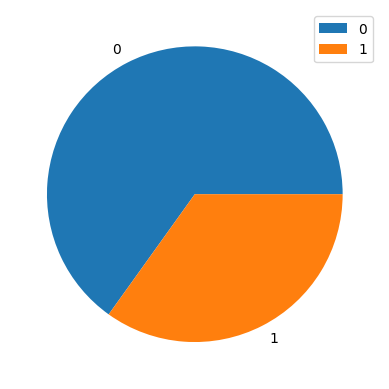

In [ ]:
crosstab = pd.crosstab(index=df['Outcome'], columns='ratio', normalize=True)
crosstab.plot(kind='pie', y='ratio')


# weights=balanced oder under-/oversampling

<Axes: >

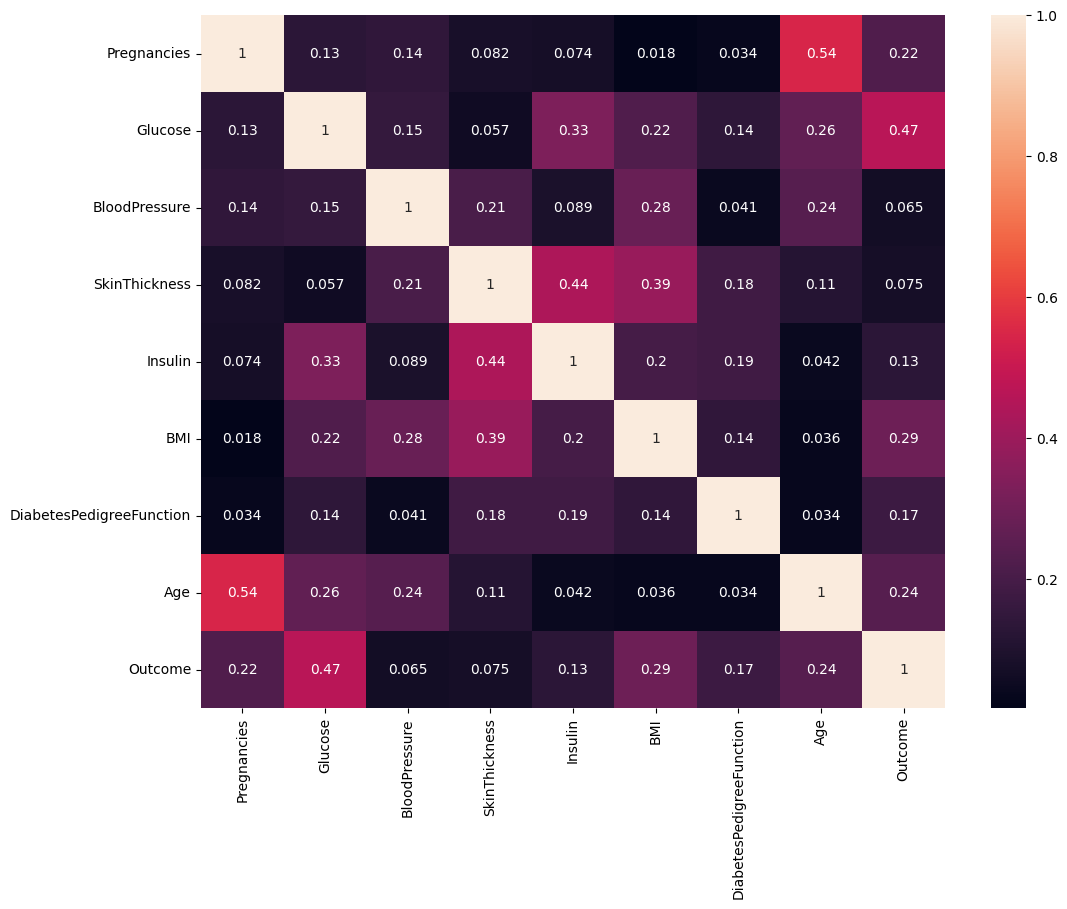

In [13]:
plt.figure(figsize=(12,9))
sns.heatmap(df.corr().abs(), annot=True)

#base model with Glucose

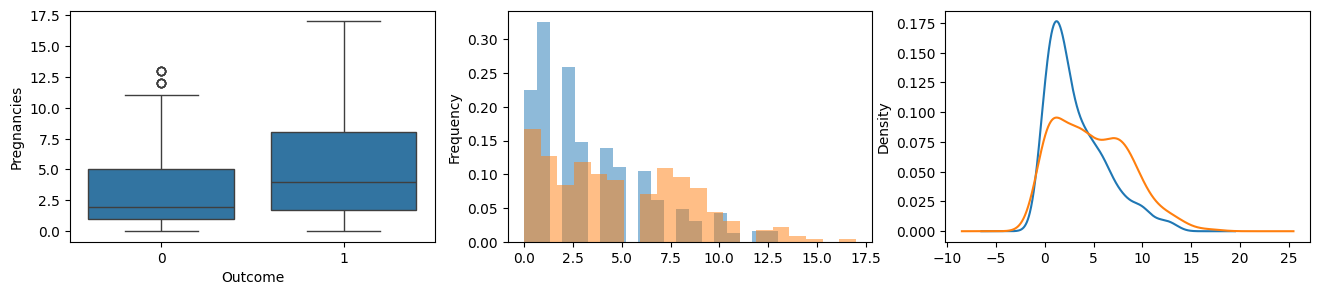

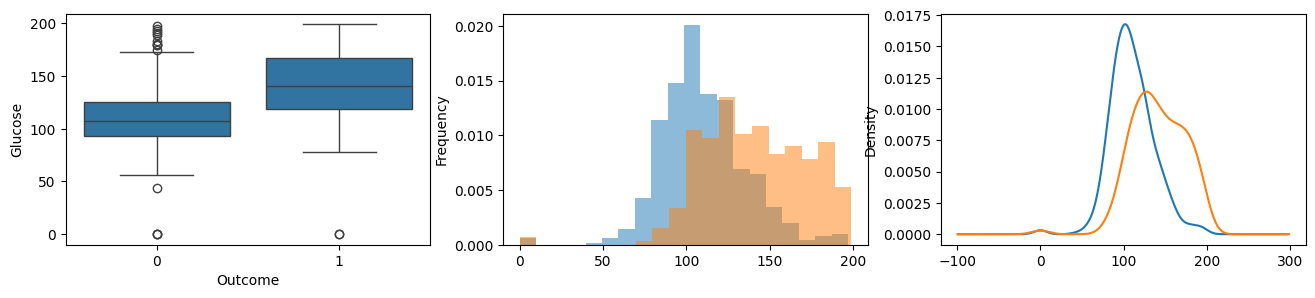

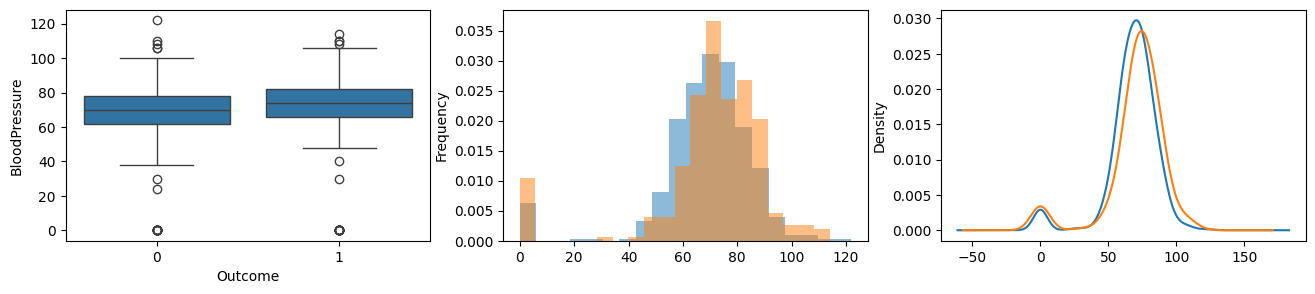

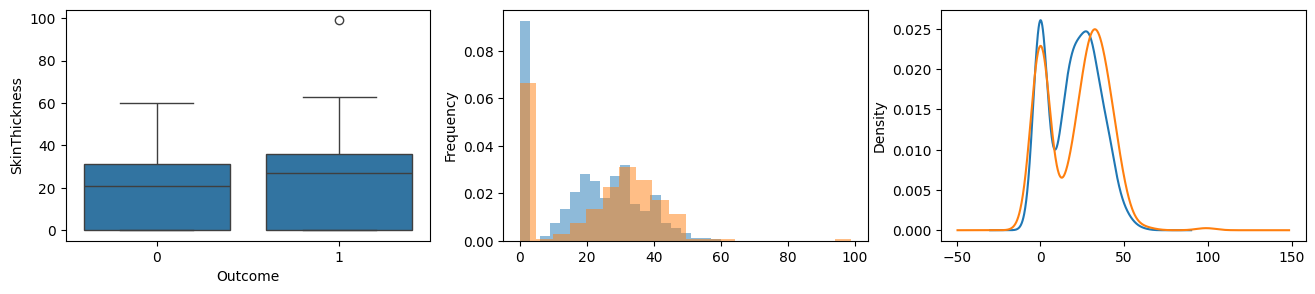

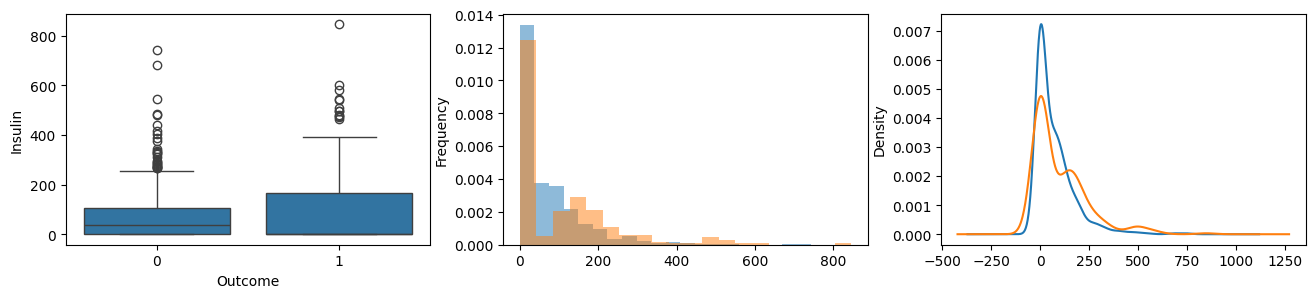

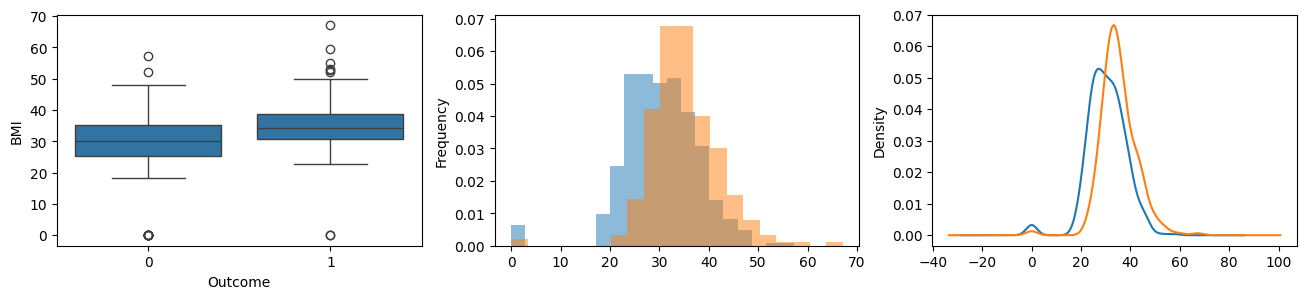

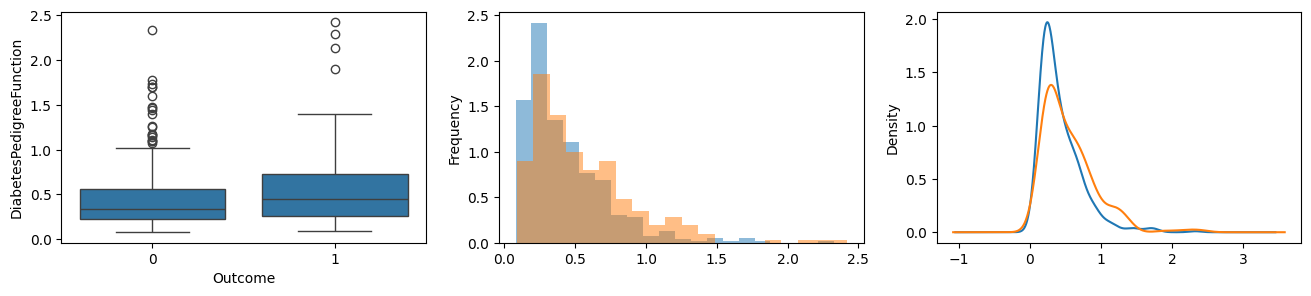

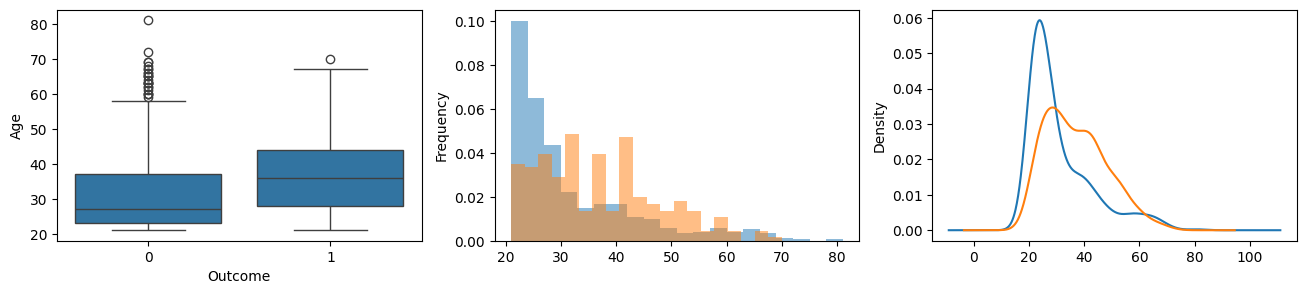

In [19]:
def numplots(col, data=df, key='Outcome', save_plot=False):
    '''Plot a histogram, boxplot and kernel density estimation (kde) plot, grouped by 'key'
    ARGS
        col: Column to plot
        data: DataFrame (default: df)
        key: Target column (default: 'Outcome')
        save_plot (bool): Save plot as image file (default: False)
    RETURN: None
    '''
    fig, ax = plt.subplots(ncols=3, figsize=(16,3))
    sns.boxplot(data=data, y=col, x=key, ax=ax[0])
    data.groupby(key)[col].plot(kind='hist', bins=20, ax=ax[1], alpha=0.5, density=True) # Der Parameter density=True ist v.a. bei unausgeglichenen Zielvariablen nützlich
    data.groupby(key)[col].plot(kind='kde', ax=ax[2])

    if save_plot:
        fig.savefig(f"numplot_{col}.png")

for feature in df.columns:
    if feature != "Outcome":
        numplots(feature)

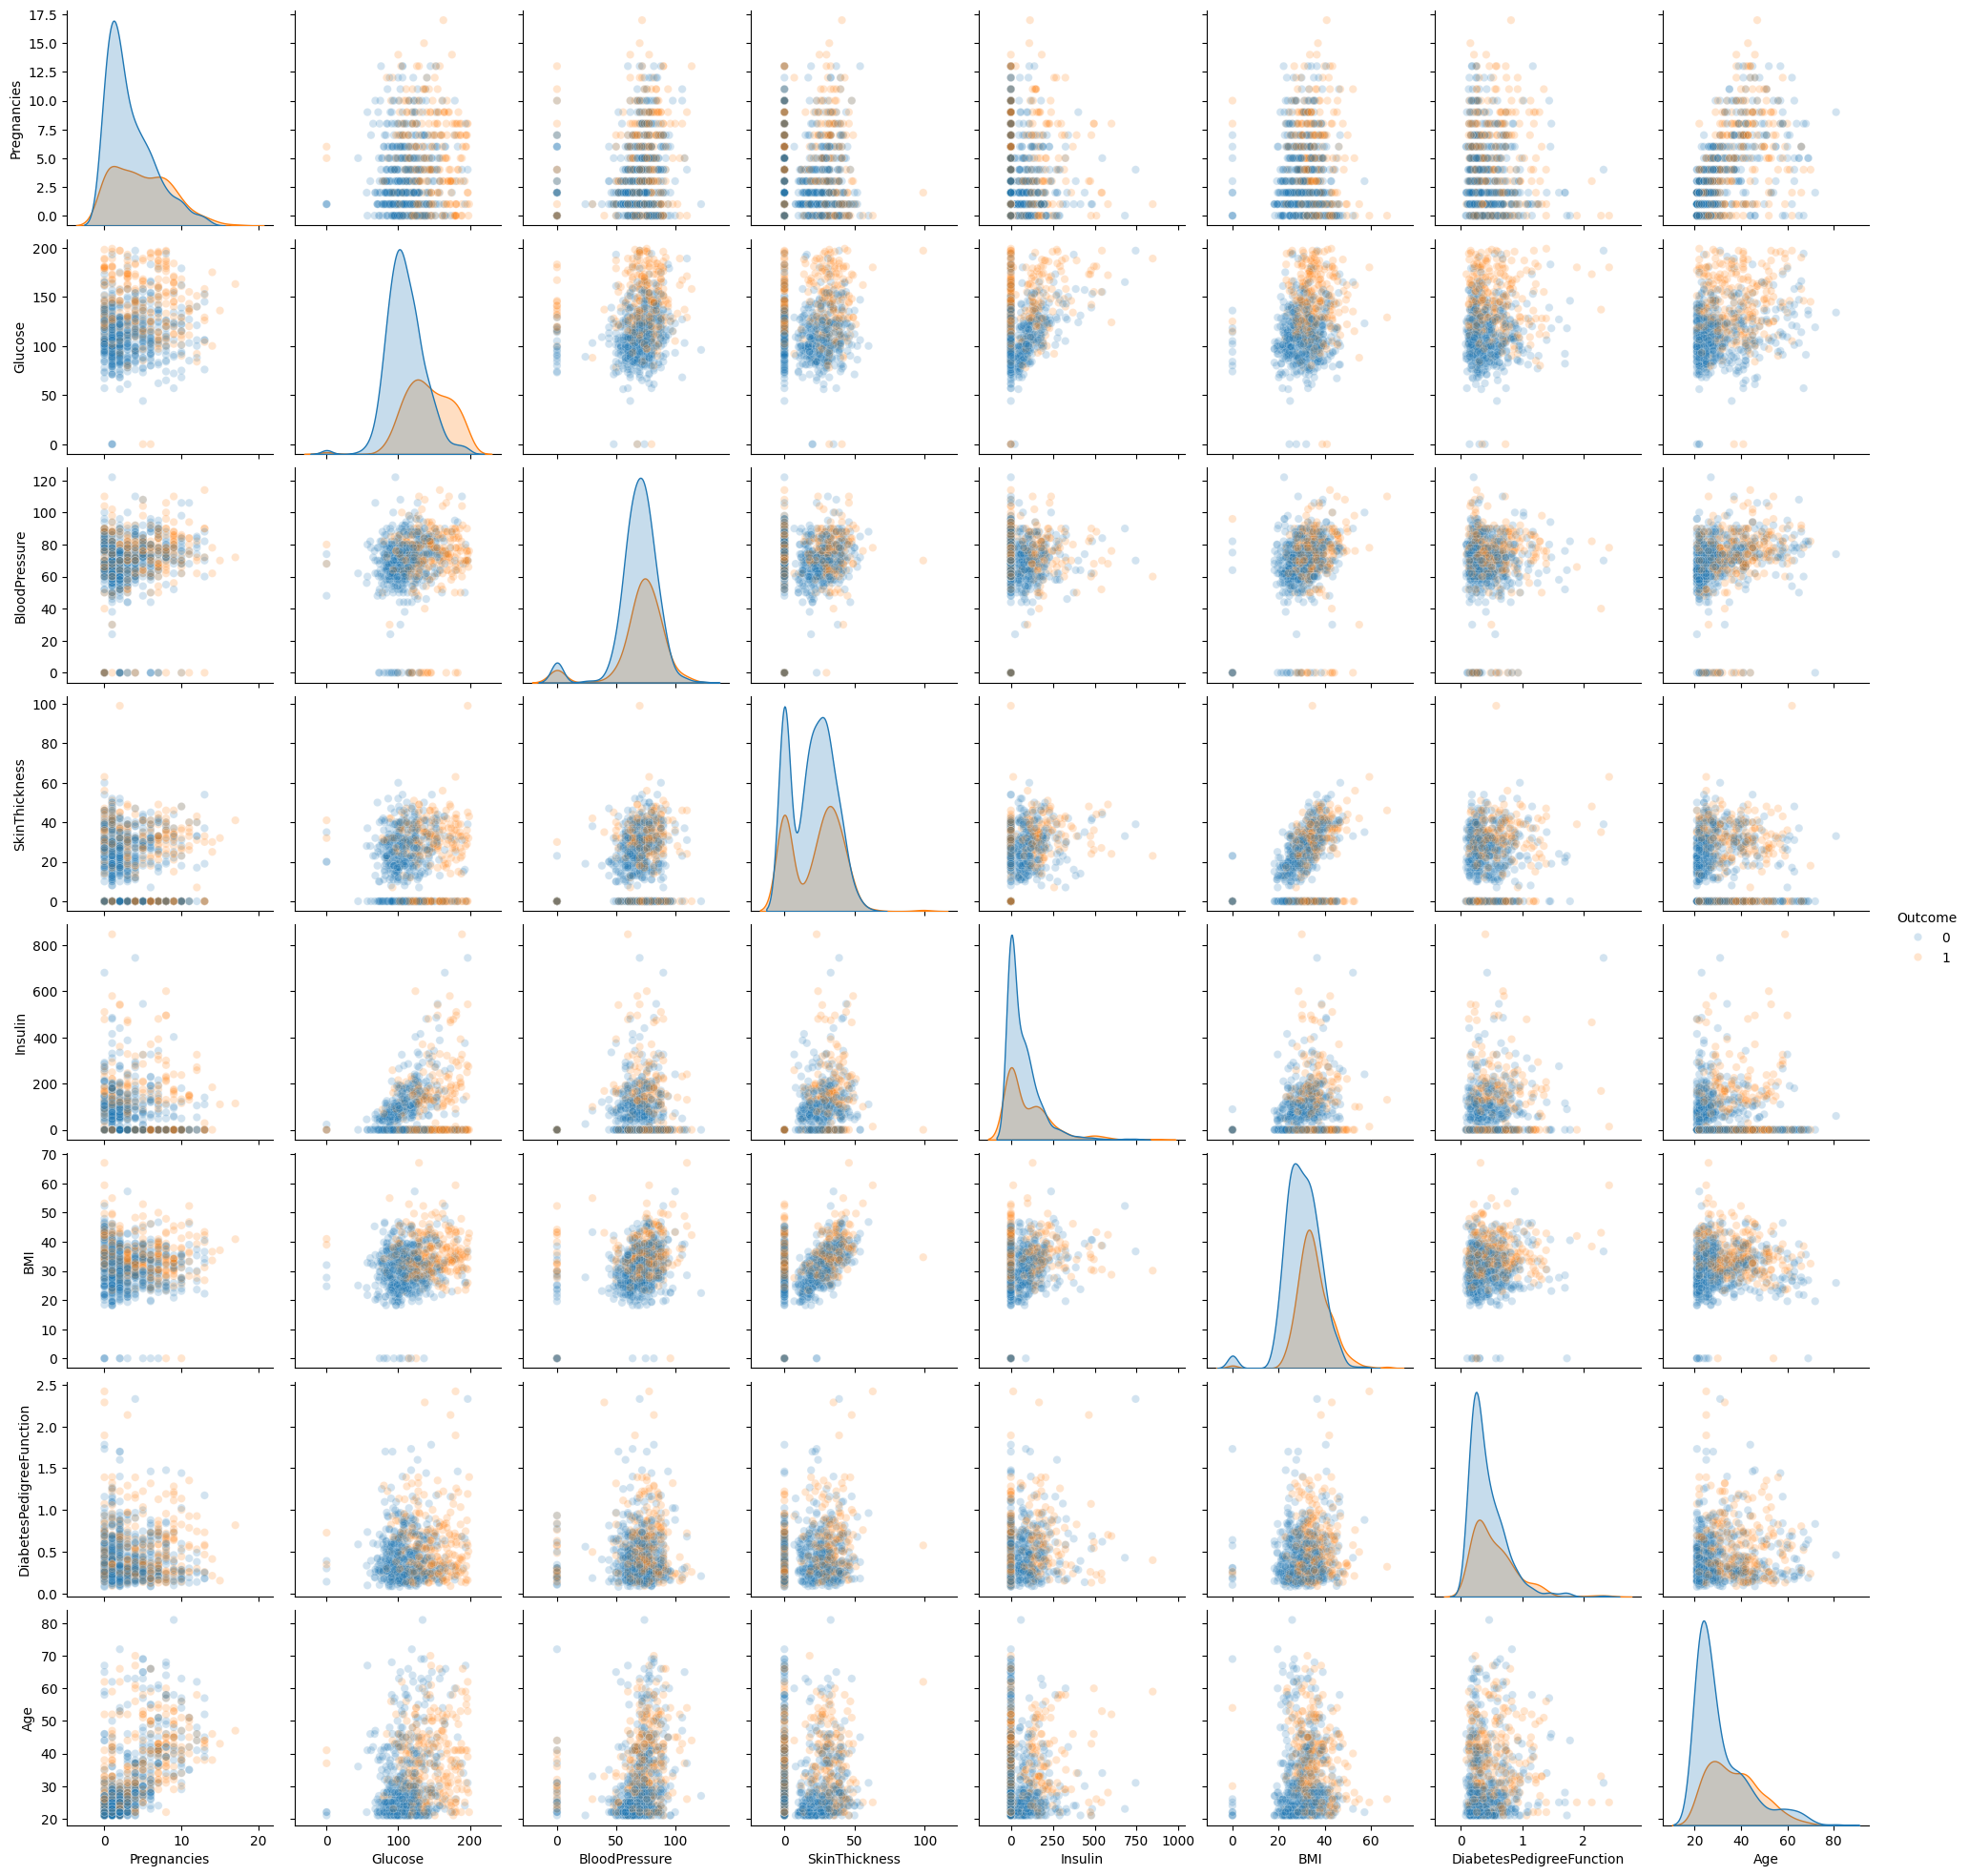

In [20]:
sns.pairplot(data=df, hue='Outcome', plot_kws={'alpha': 0.2})